<a href="https://colab.research.google.com/github/Khushi310105/Final_Year_Project/blob/main/Schizophrenia(Convo1D%2CChrononet%2CEEGNet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne

%matplotlib inline

import os
from glob import glob
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats
from tqdm import tqdm

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, Conv2D, BatchNormalization, LeakyReLU, MaxPool1D,
    GlobalAveragePooling1D, Dense, Dropout, AveragePooling1D,
    Input, Concatenate, GRU, Flatten, DepthwiseConv2D,
    SeparableConv2D, AveragePooling2D
)
from tensorflow.keras.backend import clear_session

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!find . -name "*.edf" | head -20

In [4]:
!unzip "/content/drive/MyDrive/dataverse_files.zip" -d .

Archive:  /content/drive/MyDrive/dataverse_files.zip
  inflating: ./h01.edf               
  inflating: ./h02.edf               
  inflating: ./h03.edf               
  inflating: ./h04.edf               
  inflating: ./h05.edf               
  inflating: ./h06.edf               
  inflating: ./h07.edf               
  inflating: ./h08.edf               
  inflating: ./h09.edf               
  inflating: ./h10.edf               
  inflating: ./h11.edf               
  inflating: ./h12.edf               
  inflating: ./h13.edf               
  inflating: ./h14.edf               
  inflating: ./s01.edf               
  inflating: ./s02.edf               
  inflating: ./s03.edf               
  inflating: ./s04.edf               
  inflating: ./s05.edf               
  inflating: ./s06.edf               
  inflating: ./s07.edf               
  inflating: ./s08.edf               
  inflating: ./s09.edf               
  inflating: ./s10.edf               
  inflating: ./s11.edf             

In [5]:
from glob import glob
import os

dataset_path = "/content/**/*.edf"

all_files_path = glob(dataset_path, recursive=True)

print("Total EDF files:", len(all_files_path))

healthy_file_path = [
    i for i in all_files_path
    if 'h' in os.path.basename(i)
]

patient_file_path = [
    i for i in all_files_path
    if 's' in os.path.basename(i)
]

print("Healthy files:", len(healthy_file_path))
print("Patient files:", len(patient_file_path))

Total EDF files: 28
Healthy files: 14
Patient files: 14


In [6]:
def read_data(file_path):
    datax = mne.io.read_raw_edf(file_path, preload=True)

    # Referencing
    datax.set_eeg_reference()

    # Filtering
    datax.filter(l_freq=1, h_freq=45)

    # 25-second epochs
    epochs = mne.make_fixed_length_epochs(
        datax,
        duration=25,
        overlap=0
    )

    epochs = epochs.get_data()

    return epochs   # (trials, channels, length)

In [7]:
sample = read_data(healthy_file_path[0])
print("Sample shape:", sample.shape)

Extracting EDF parameters from /content/h01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 825 samples (3.300 s)

Not setting metadata
37 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 37 events and 6

In [8]:
control_epochs_array = [
    read_data(subject)
    for subject in healthy_file_path
]

patients_epochs_array = [
    read_data(subject)
    for subject in patient_file_path
]

# Labels
control_epochs_labels = [
    len(i) * [0]
    for i in control_epochs_array
]

patients_epochs_labels = [
    len(i) * [1]
    for i in patients_epochs_array
]

print("Healthy subjects:", len(control_epochs_labels))
print("Patient subjects:", len(patients_epochs_labels))

Extracting EDF parameters from /content/h01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 825 samples (3.300 s)

Not setting metadata
37 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 37 events and 6

In [9]:
data_list = control_epochs_array + patients_epochs_array
label_list = control_epochs_labels + patients_epochs_labels

# subject-wise groups
groups_list = [
    [i] * len(j)
    for i, j in enumerate(data_list)
]

# final arrays
data_array = np.vstack(data_list)
label_array = np.hstack(label_list)
group_array = np.hstack(groups_list)

print("Original data shape:", data_array.shape)
print("Labels shape:", label_array.shape)
print("Groups shape:", group_array.shape)

# move to (samples, time, channels)
data_array = np.moveaxis(data_array, 1, 2)

print("Final data shape:", data_array.shape)

Original data shape: (1142, 19, 6250)
Labels shape: (1142,)
Groups shape: (1142,)
Final data shape: (1142, 6250, 19)


In [10]:
def cnnmodel():

    clear_session()

    model = Sequential()

    model.add(
        Conv1D(
            filters=5,
            kernel_size=3,
            strides=1,
            input_shape=(6250, 19)
        )
    )
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(MaxPool1D(pool_size=2, strides=2))

    model.add(Conv1D(filters=5, kernel_size=3))
    model.add(LeakyReLU())
    model.add(MaxPool1D(pool_size=2, strides=2))
    model.add(Dropout(0.5))

    model.add(Conv1D(filters=5, kernel_size=3))
    model.add(LeakyReLU())
    model.add(AveragePooling1D(pool_size=2, strides=2))
    model.add(Dropout(0.5))

    model.add(Conv1D(filters=5, kernel_size=3))
    model.add(LeakyReLU())
    model.add(AveragePooling1D(pool_size=2, strides=2))

    model.add(Conv1D(filters=5, kernel_size=3))
    model.add(LeakyReLU())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [11]:
def chrononet():

    clear_session()

    input_layer = Input(shape=(6250, 19))

    conv1 = Conv1D(32, 2, strides=2, padding='same', activation='relu')(input_layer)
    conv2 = Conv1D(32, 4, strides=2, padding='same', activation='relu')(input_layer)
    conv3 = Conv1D(32, 8, strides=2, padding='same', activation='relu')(input_layer)

    x = Concatenate()([conv1, conv2, conv3])

    conv4 = Conv1D(32, 2, strides=2, padding='same', activation='relu')(x)
    conv5 = Conv1D(32, 4, strides=2, padding='same', activation='relu')(x)
    conv6 = Conv1D(32, 8, strides=2, padding='same', activation='relu')(x)

    x = Concatenate()([conv4, conv5, conv6])

    x = GRU(32, return_sequences=True)(x)
    x = GRU(32, return_sequences=True)(x)
    x = GRU(32)(x)

    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=output)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [12]:
def eegnet():

    clear_session()

    input_layer = Input(shape=(19, 6250, 1))

    x = Conv2D(8, (1, 64), padding='same', use_bias=False)(input_layer)
    x = BatchNormalization()(x)

    x = DepthwiseConv2D((19, 1), use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(0.5)(x)

    x = SeparableConv2D(16, (1, 16), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(0.5)(x)

    x = Flatten()(x)

    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=output)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [13]:
def train_and_evaluate(model_fn, X, y, groups, model_name):

    gkf = GroupKFold(n_splits=5)

    all_true = []
    all_pred = []

    train_acc_histories = []
    val_acc_histories = []

    train_loss_histories = []
    val_loss_histories = []

    fold_accuracies = []

    fold = 1

    for train_index, val_index in gkf.split(X, y, groups):

        print(f"\n========== {model_name} | Fold {fold} ==========")

        X_train = X[train_index]
        y_train = y[train_index]

        X_val = X[val_index]
        y_val = y[val_index]

        # CNN / ChronoNet scaling
        if model_name != "EEGNet":
            scaler = StandardScaler()

            X_train = scaler.fit_transform(
                X_train.reshape(-1, X_train.shape[-1])
            ).reshape(X_train.shape)

            X_val = scaler.transform(
                X_val.reshape(-1, X_val.shape[-1])
            ).reshape(X_val.shape)

        # EEGNet reshape
        if model_name == "EEGNet":
            X_train = np.transpose(X_train, (0, 2, 1))
            X_val = np.transpose(X_val, (0, 2, 1))

            X_train = X_train[..., np.newaxis]
            X_val = X_val[..., np.newaxis]

        model = model_fn()

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=128,
            validation_data=(X_val, y_val),
            verbose=1
        )

        preds = model.predict(X_val)
        preds = (preds > 0.5).astype(int).flatten()

        all_true.extend(y_val)
        all_pred.extend(preds)

        loss, acc = model.evaluate(X_val, y_val, verbose=0)

        print(f"Fold {fold} Accuracy: {acc:.4f}")

        fold_accuracies.append(acc)

        train_acc_histories.append(history.history['accuracy'])
        val_acc_histories.append(history.history['val_accuracy'])

        train_loss_histories.append(history.history['loss'])
        val_loss_histories.append(history.history['val_loss'])

        # fold graph
        plt.figure(figsize=(6,4))
        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Validation')
        plt.title(f"{model_name} Fold {fold} Accuracy")
        plt.legend()
        plt.show()

        fold += 1

    print(f"\nMean Accuracy ({model_name}): {np.mean(fold_accuracies):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_true, all_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Healthy', 'Patient']
    )

    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    print(classification_report(all_true, all_pred))

    # Mean Accuracy Graph
    mean_train_acc = np.mean(train_acc_histories, axis=0)
    mean_val_acc = np.mean(val_acc_histories, axis=0)

    plt.figure(figsize=(8,5))
    plt.plot(mean_train_acc, label='Train Accuracy')
    plt.plot(mean_val_acc, label='Validation Accuracy')
    plt.title(f"{model_name} Mean Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Mean Loss Graph
    mean_train_loss = np.mean(train_loss_histories, axis=0)
    mean_val_loss = np.mean(val_loss_histories, axis=0)

    plt.figure(figsize=(8,5))
    plt.plot(mean_train_loss, label='Train Loss')
    plt.plot(mean_val_loss, label='Validation Loss')
    plt.title(f"{model_name} Mean Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    return all_true, all_pred


========== CNN | Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 877ms/step - accuracy: 0.4446 - loss: 0.6985 - val_accuracy: 0.4026 - val_loss: 0.6971
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5137 - loss: 0.6927 - val_accuracy: 0.5152 - val_loss: 0.6911
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5543 - loss: 0.6886 - val_accuracy: 0.5195 - val_loss: 0.6866
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5554 - loss: 0.6849 - val_accuracy: 0.5195 - val_loss: 0.6818
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5554 - loss: 0.6832 - val_accuracy: 0.5195 - val_loss: 0.6779
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5554 - loss: 0.6806 - val_accuracy: 0.5195 - val_loss: 0.6740
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5554 - loss: 0.6782 - val_accuracy: 0.5195 - val_loss: 0.6703
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5554 - loss: 0.6782 - val_accuracy: 0.5195 - val_loss: 0.66

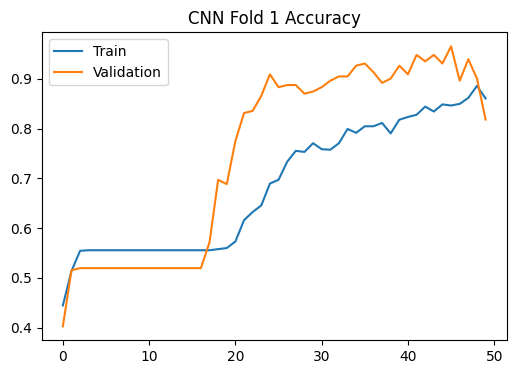


========== CNN | Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 858ms/step - accuracy: 0.5481 - loss: 0.6886 - val_accuracy: 0.4709 - val_loss: 0.6934
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5652 - loss: 0.6819 - val_accuracy: 0.4709 - val_loss: 0.6961
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5652 - loss: 0.6751 - val_accuracy: 0.4709 - val_loss: 0.6991
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5652 - loss: 0.6670 - val_accuracy: 0.4709 - val_loss: 0.7038
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5652 - loss: 0.6660 - val_accuracy: 0.4709 - val_loss: 0.7077
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5652 - loss: 0.6594 - val_accuracy: 0.4709 - val_loss: 0.7060
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5652 - loss: 0.6566 - val_accuracy: 0.4709 - val_loss: 0.7027
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5652 - loss: 0.6503 - val_accuracy: 0.4709 - val_loss: 0.703

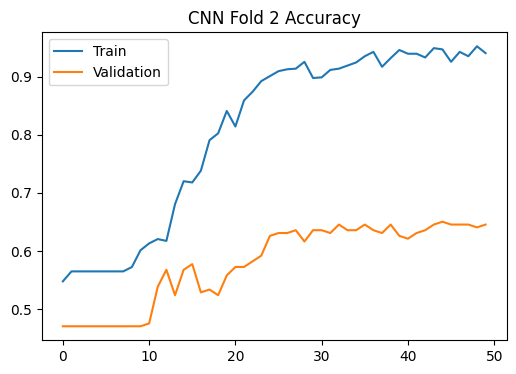


========== CNN | Fold 3 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 815ms/step - accuracy: 0.4394 - loss: 0.9022 - val_accuracy: 0.5000 - val_loss: 0.7697
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4394 - loss: 0.7769 - val_accuracy: 0.5043 - val_loss: 0.7368
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4438 - loss: 0.7329 - val_accuracy: 0.4316 - val_loss: 0.7222
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.4681 - loss: 0.7050 - val_accuracy: 0.4744 - val_loss: 0.7165
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5231 - loss: 0.6963 - val_accuracy: 0.4915 - val_loss: 0.7135
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5639 - loss: 0.6880 - val_accuracy: 0.4915 - val_loss: 0.7112
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5628 - loss: 0.6850 - val_accuracy: 0.4915 - val_loss: 0.7101
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5595 - loss: 0.6827 - val_accuracy: 0.4915 - val_loss: 0.709

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
Fold 3 Accuracy: 0.6496


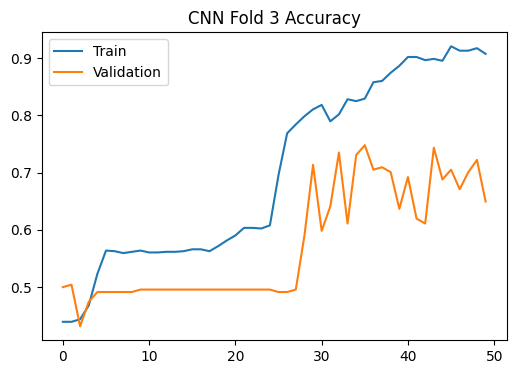


========== CNN | Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 690ms/step - accuracy: 0.5486 - loss: 0.6894 - val_accuracy: 0.5466 - val_loss: 0.6913
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5486 - loss: 0.6862 - val_accuracy: 0.5466 - val_loss: 0.6904
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5486 - loss: 0.6830 - val_accuracy: 0.5466 - val_loss: 0.6896
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.5486 - loss: 0.6792 - val_accuracy: 0.5466 - val_loss: 0.6891
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5486 - loss: 0.6782 - val_accuracy: 0.5466 - val_loss: 0.6889
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5486 - loss: 0.6743 - val_accuracy: 0.5466 - val_loss: 0.6887
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5486 - loss: 0.6703 - val_accuracy: 0.5466 - val_loss: 0.6887
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5486 - loss: 0.6708 - val_accuracy: 0.5466 - val_loss: 0.688

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
Fold 4 Accuracy: 0.6017


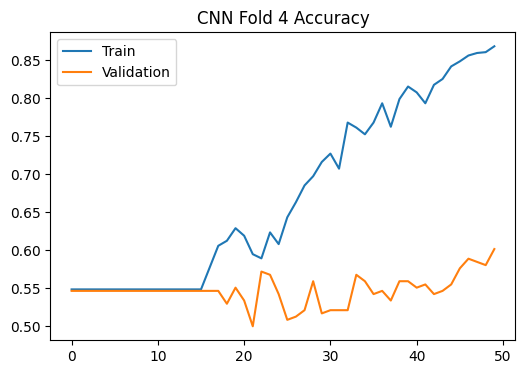


========== CNN | Fold 5 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 703ms/step - accuracy: 0.5105 - loss: 0.6876 - val_accuracy: 0.6936 - val_loss: 0.6876
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5105 - loss: 0.6849 - val_accuracy: 0.6936 - val_loss: 0.6845
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5138 - loss: 0.6804 - val_accuracy: 0.7617 - val_loss: 0.6841
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5171 - loss: 0.6760 - val_accuracy: 0.7106 - val_loss: 0.6789
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5160 - loss: 0.6693 - val_accuracy: 0.7787 - val_loss: 0.6776
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5259 - loss: 0.6611 - val_accuracy: 0.7447 - val_loss: 0.6796
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5557 - loss: 0.6513 - val_accuracy: 0.5702 - val_loss: 0.6875
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5921 - loss: 0.6407 - val_accuracy: 0.4000 - val_loss: 0.693

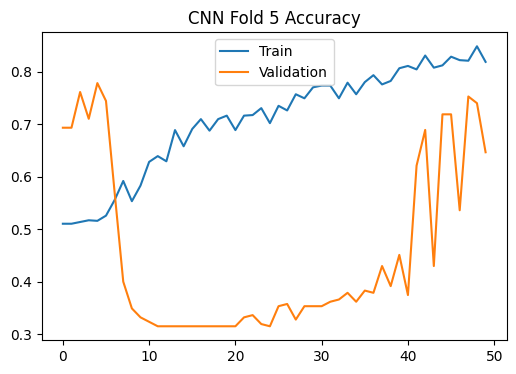


Mean Accuracy (CNN): 0.6724


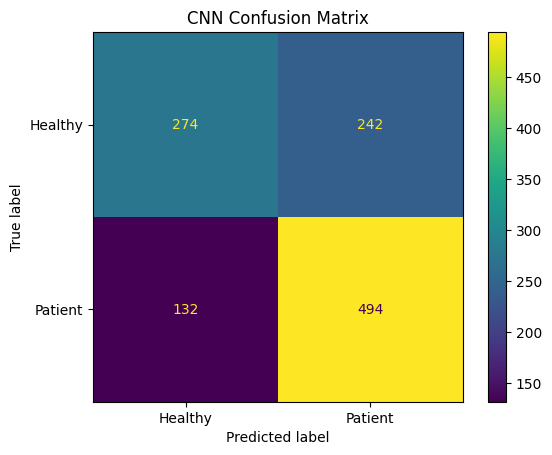

              precision    recall  f1-score   support

           0       0.67      0.53      0.59       516
           1       0.67      0.79      0.73       626

    accuracy                           0.67      1142
   macro avg       0.67      0.66      0.66      1142
weighted avg       0.67      0.67      0.67      1142



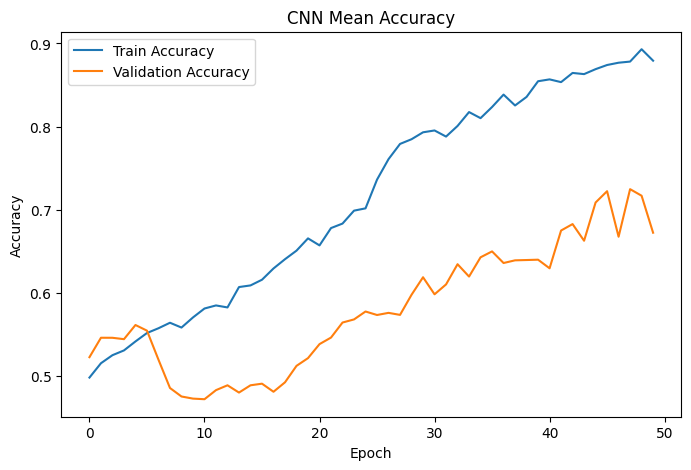

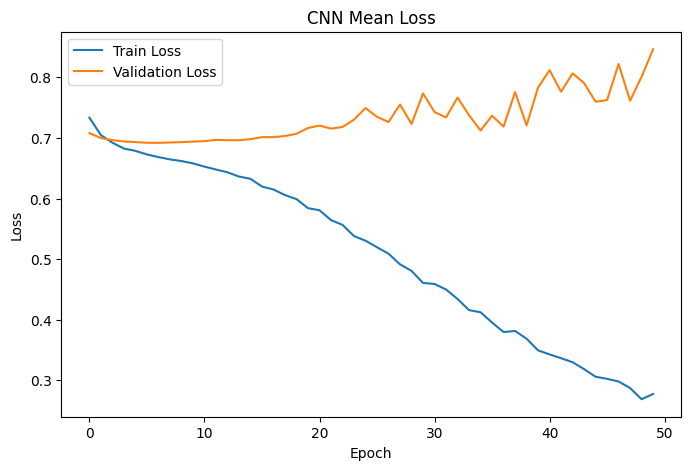

In [14]:
cnn_true, cnn_pred = train_and_evaluate(
    model_fn=cnnmodel,
    X=data_array,
    y=label_array,
    groups=group_array,
    model_name="CNN"
)


========== ChronoNet | Fold 1 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 768ms/step - accuracy: 0.5598 - loss: 0.6837 - val_accuracy: 0.5195 - val_loss: 0.6719
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.6158 - loss: 0.6684 - val_accuracy: 0.5281 - val_loss: 0.6599
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.6048 - loss: 0.6476 - val_accuracy: 0.5671 - val_loss: 0.6441
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.6608 - loss: 0.6187 - val_accuracy: 0.6537 - val_loss: 0.6151
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.6718 - loss: 0.5869 - val_accuracy: 0.6710 - val_loss: 0.5911
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 335ms/step - accuracy: 0.7278 - loss: 0.5379 - val_accuracy: 0.5844 - val_loss: 0.7661
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.7278 - loss: 0.5339 - val_accuracy: 0.7532 - val_loss: 0.5515
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.7717 - loss

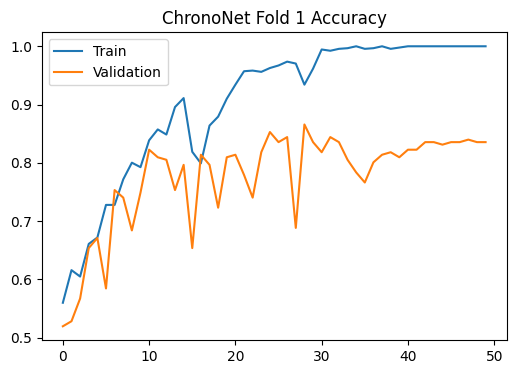


========== ChronoNet | Fold 2 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 417ms/step - accuracy: 0.5662 - loss: 0.6787 - val_accuracy: 0.4806 - val_loss: 0.7120
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.5994 - loss: 0.6566 - val_accuracy: 0.5194 - val_loss: 0.6918
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.6293 - loss: 0.6328 - val_accuracy: 0.5146 - val_loss: 0.6944
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 303ms/step - accuracy: 0.6998 - loss: 0.5785 - val_accuracy: 0.5583 - val_loss: 0.6921
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.7650 - loss: 0.5022 - val_accuracy: 0.5922 - val_loss: 0.7607
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - accuracy: 0.7746 - loss: 0.4666 - val_accuracy: 0.5728 - val_loss: 0.9200
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.8130 - loss: 0.4151 - val_accuracy: 0.6117 - val_loss: 0.8333
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.8269 - loss:

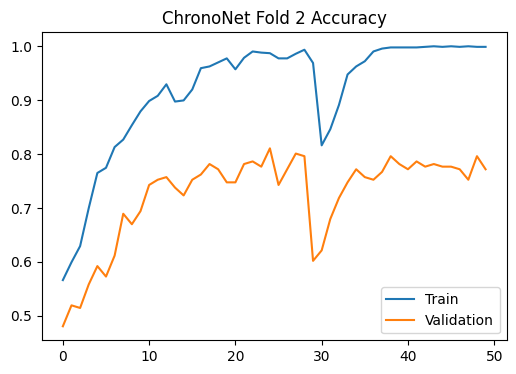


========== ChronoNet | Fold 3 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 404ms/step - accuracy: 0.5529 - loss: 0.6847 - val_accuracy: 0.5043 - val_loss: 0.7111
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - accuracy: 0.5606 - loss: 0.6628 - val_accuracy: 0.5043 - val_loss: 0.7002
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 0.6233 - loss: 0.6391 - val_accuracy: 0.5598 - val_loss: 0.6853
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.6916 - loss: 0.6001 - val_accuracy: 0.6068 - val_loss: 0.6887
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.7379 - loss: 0.5356 - val_accuracy: 0.6282 - val_loss: 0.6742
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.8018 - loss: 0.4521 - val_accuracy: 0.6111 - val_loss: 0.7507
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.8161 - loss: 0.4238 - val_accuracy: 0.6197 - val_loss: 0.8061
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.7985 - loss:

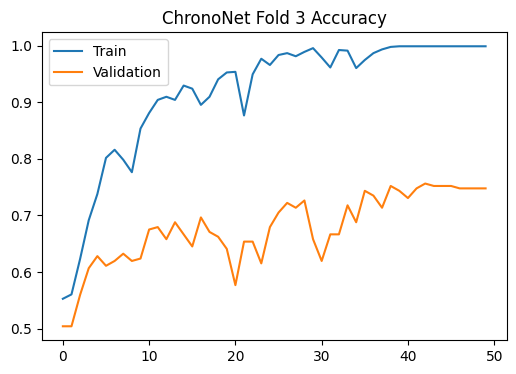


========== ChronoNet | Fold 4 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 391ms/step - accuracy: 0.5530 - loss: 0.6761 - val_accuracy: 0.5466 - val_loss: 0.7054
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.6192 - loss: 0.6510 - val_accuracy: 0.5424 - val_loss: 0.6965
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.6755 - loss: 0.6149 - val_accuracy: 0.5381 - val_loss: 0.6959
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step - accuracy: 0.7528 - loss: 0.5347 - val_accuracy: 0.5593 - val_loss: 0.7274
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.8013 - loss: 0.4525 - val_accuracy: 0.5720 - val_loss: 0.7938
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.8212 - loss: 0.4244 - val_accuracy: 0.5932 - val_loss: 0.8689
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 255ms/step - accuracy: 0.8168 - loss: 0.3946 - val_accuracy: 0.6017 - val_loss: 0.8155
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.8311 - loss:

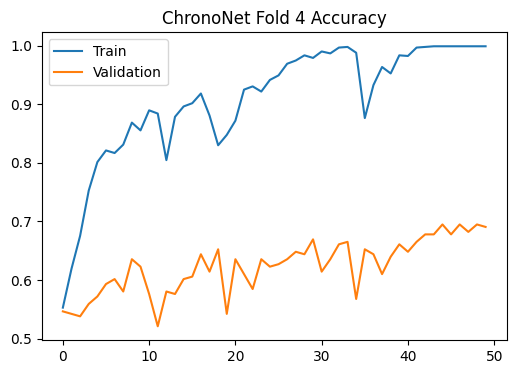


========== ChronoNet | Fold 5 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 404ms/step - accuracy: 0.5436 - loss: 0.6807 - val_accuracy: 0.3277 - val_loss: 0.7605
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.6295 - loss: 0.6452 - val_accuracy: 0.6979 - val_loss: 0.6213
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.6439 - loss: 0.6171 - val_accuracy: 0.6128 - val_loss: 0.6875
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step - accuracy: 0.7133 - loss: 0.5513 - val_accuracy: 0.5447 - val_loss: 0.7702
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 0.7916 - loss: 0.4711 - val_accuracy: 0.6638 - val_loss: 0.7139
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.8148 - loss: 0.4141 - val_accuracy: 0.6213 - val_loss: 0.8542
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - accuracy: 0.8269 - loss: 0.3660 - val_accuracy: 0.5319 - val_loss: 1.1095
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 255ms/step - accuracy: 0.8467 - loss:

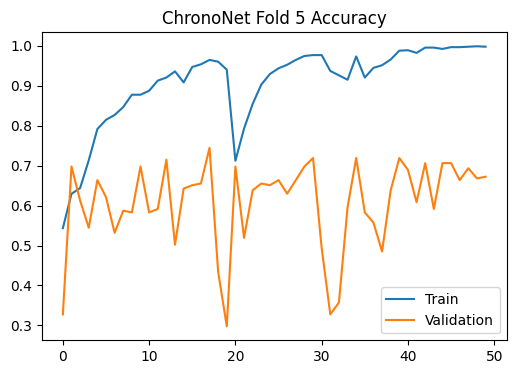


Mean Accuracy (ChronoNet): 0.7436


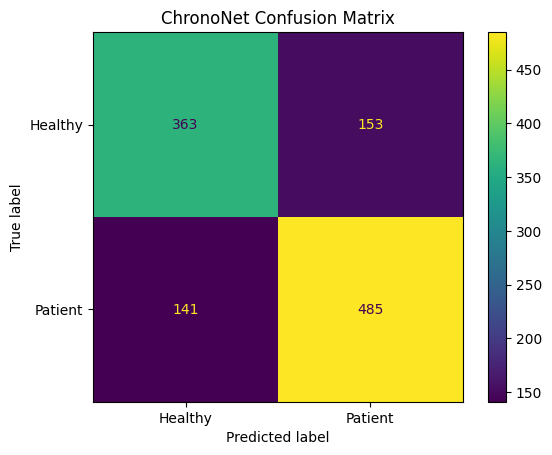

              precision    recall  f1-score   support

           0       0.72      0.70      0.71       516
           1       0.76      0.77      0.77       626

    accuracy                           0.74      1142
   macro avg       0.74      0.74      0.74      1142
weighted avg       0.74      0.74      0.74      1142



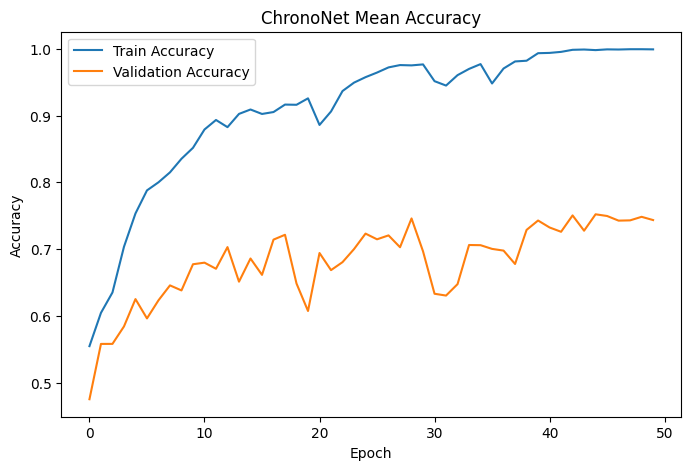

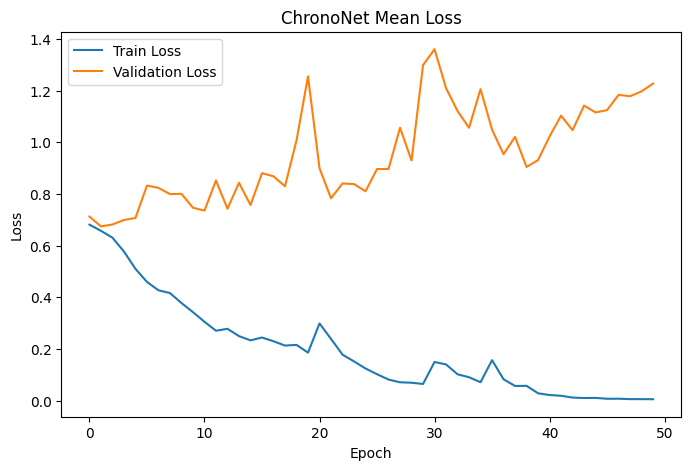

In [15]:
chrono_true, chrono_pred = train_and_evaluate(
    model_fn=chrononet,
    X=data_array,
    y=label_array,
    groups=group_array,
    model_name="ChronoNet"
)


========== EEGNet | Fold 1 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5532 - loss: 0.6884 - val_accuracy: 0.5195 - val_loss: 0.6924
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 213ms/step - accuracy: 0.5554 - loss: 0.6842 - val_accuracy: 0.5195 - val_loss: 0.6924
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.5554 - loss: 0.6809 - val_accuracy: 0.5195 - val_loss: 0.6925
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.5543 - loss: 0.6706 - val_accuracy: 0.5195 - val_loss: 0.6925
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.5576 - loss: 0.6626 - val_accuracy: 0.4805 - val_loss: 0.6933
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.6202 - loss: 0.6497 - val_accuracy: 0.4805 - val_loss: 0.6946
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.6663 - loss: 0.6388 - val_accuracy: 0.4805 - val_loss: 0.6947
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - accuracy: 0.6608 - loss: 0.6

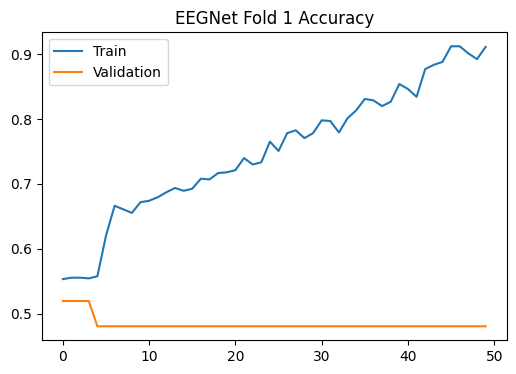


========== EEGNet | Fold 2 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5502 - loss: 0.6895 - val_accuracy: 0.4709 - val_loss: 0.6958
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.5652 - loss: 0.6815 - val_accuracy: 0.4709 - val_loss: 0.6976
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.5652 - loss: 0.6791 - val_accuracy: 0.4709 - val_loss: 0.6994
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step - accuracy: 0.5662 - loss: 0.6730 - val_accuracy: 0.4709 - val_loss: 0.6980
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.5662 - loss: 0.6656 - val_accuracy: 0.4709 - val_loss: 0.6987
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.5673 - loss: 0.6528 - val_accuracy: 0.4709 - val_loss: 0.7026
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.5737 - loss: 0.6367 - val_accuracy: 0.4709 - val_loss: 0.7027
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.6496 - loss: 0.62

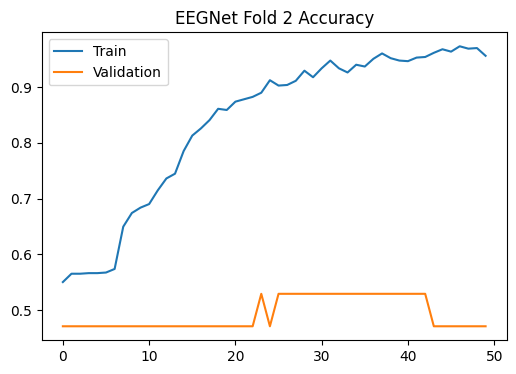


========== EEGNet | Fold 3 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5606 - loss: 0.6852 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 220ms/step - accuracy: 0.5606 - loss: 0.6845 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.5606 - loss: 0.6807 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.5606 - loss: 0.6780 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.5606 - loss: 0.6704 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.5606 - loss: 0.6628 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.5661 - loss: 0.6525 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.6421 - loss: 0.6

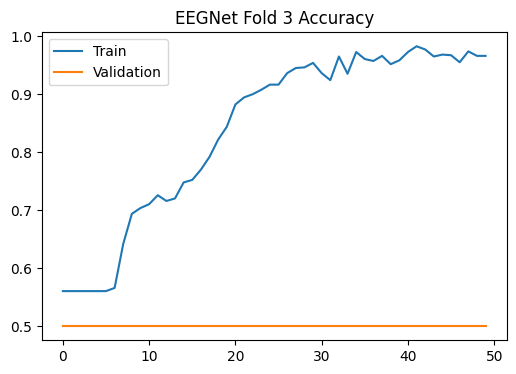


========== EEGNet | Fold 4 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5419 - loss: 0.6898 - val_accuracy: 0.5466 - val_loss: 0.6911
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.5464 - loss: 0.6861 - val_accuracy: 0.5466 - val_loss: 0.6918
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.5486 - loss: 0.6834 - val_accuracy: 0.5466 - val_loss: 0.6913
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.5486 - loss: 0.6788 - val_accuracy: 0.5466 - val_loss: 0.6901
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.5486 - loss: 0.6758 - val_accuracy: 0.5466 - val_loss: 0.6902
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.5497 - loss: 0.6678 - val_accuracy: 0.5466 - val_loss: 0.6902
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - accuracy: 0.5475 - loss: 0.6583 - val_accuracy: 0.5466 - val_loss: 0.6915
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.5839 - loss: 0.64

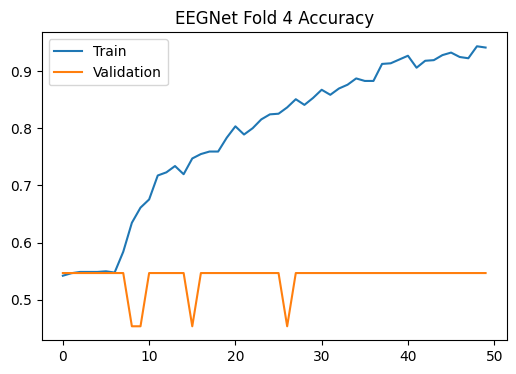


========== EEGNet | Fold 5 ==========
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5072 - loss: 0.6920 - val_accuracy: 0.6936 - val_loss: 0.6904
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.5380 - loss: 0.6890 - val_accuracy: 0.6936 - val_loss: 0.6875
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.5524 - loss: 0.6810 - val_accuracy: 0.6936 - val_loss: 0.6825
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.6064 - loss: 0.6722 - val_accuracy: 0.6936 - val_loss: 0.6899
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.6064 - loss: 0.6616 - val_accuracy: 0.3064 - val_loss: 0.6970
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.6141 - loss: 0.6473 - val_accuracy: 0.6936 - val_loss: 0.6883
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.6384 - loss: 0.6322 - val_accuracy: 0.3064 - val_loss: 0.6978
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.6307 - loss: 0.62

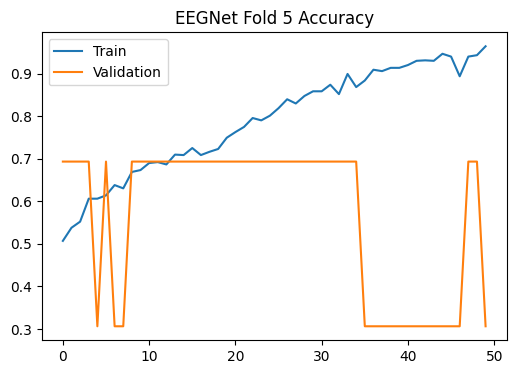


Mean Accuracy (EEGNet): 0.4609


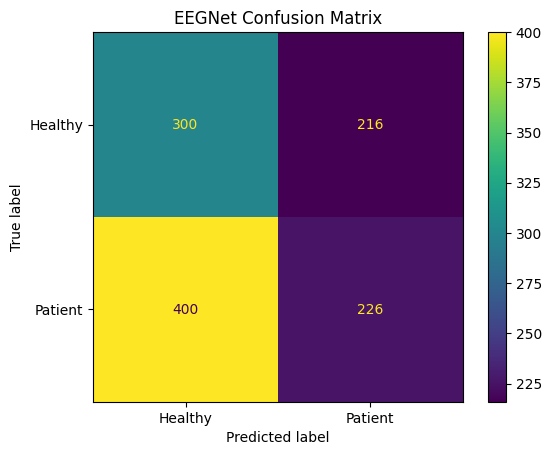

              precision    recall  f1-score   support

           0       0.43      0.58      0.49       516
           1       0.51      0.36      0.42       626

    accuracy                           0.46      1142
   macro avg       0.47      0.47      0.46      1142
weighted avg       0.47      0.46      0.45      1142



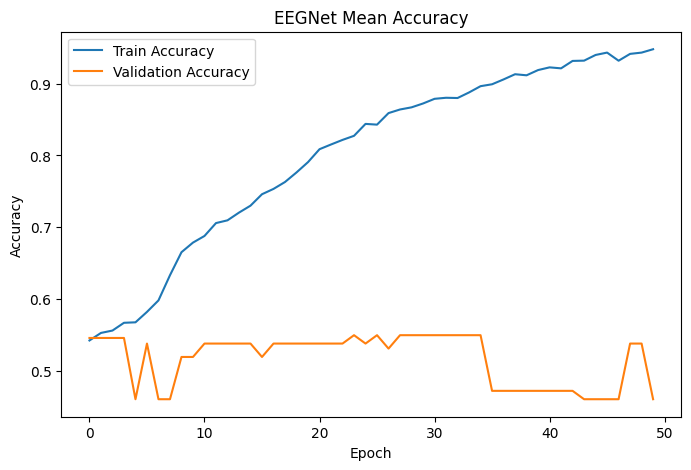

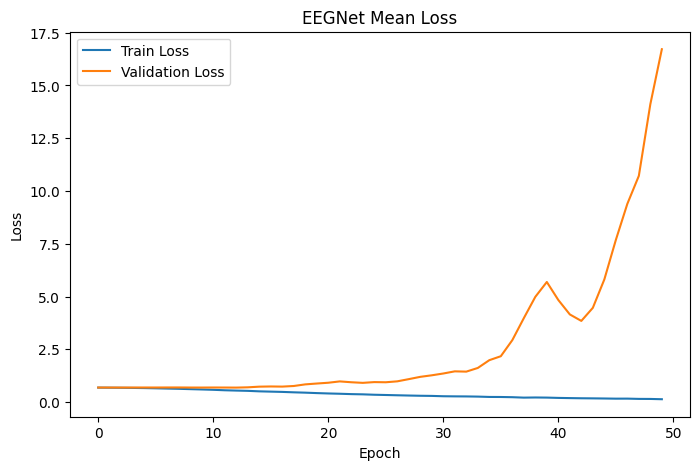

In [16]:
eeg_true, eeg_pred = train_and_evaluate(
    model_fn=eegnet,
    X=data_array,
    y=label_array,
    groups=group_array,
    model_name="EEGNet"
)